# 🛍 Mini Project — Customer Segmentation using Clustering

---

# 📌 Problem Statement

A shopping mall wants to understand its customers better.

Using customer information such as:

• Age  
• Annual Income  
• Spending Score  

The goal is to **segment customers into groups** so that marketing strategies can be customized.

---

# 🎯 Objective

Use **K-Means Clustering** to identify different types of customers.

This helps the business:

• Target high spending customers  
• Design personalized marketing campaigns  
• Improve customer experience

---

# 📂 Dataset Description

Dataset: **Mall Customers Dataset**

Features:

CustomerID  
Gender  
Age  
Annual Income (k$)  
Spending Score (1-100)

For clustering we will use:

• Annual Income  
• Spending Score

---

# 🧠 Machine Learning Workflow

1️⃣ Load dataset  
2️⃣ Select important features  
3️⃣ Apply Elbow Method  
4️⃣ Train K-Means model  
5️⃣ Visualize clusters  
6️⃣ Interpret results

---


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
# Step 2 - Load Dataset

df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
#Step 3 - Select Feature

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Elbow Method 

What is Elbow Method?<br>
It tells us how may cluser is need more to made<br>
<br>
Why?<br>
To avoid random guessing<br>
<br>
When?<br>
when we want  to group customers

In [9]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)

C:\Users\aniru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aniru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aniru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\aniru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

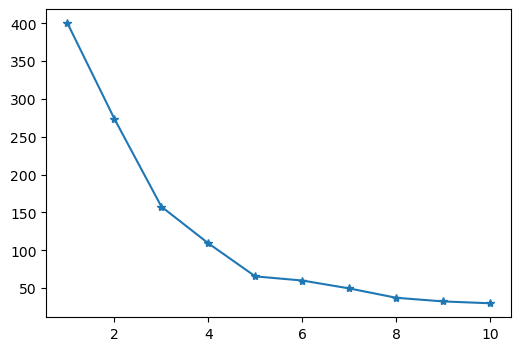

In [10]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
    model_kmeans = KMeans(
        n_clusters = i, 
        random_state = 42)
    model_kmeans.fit(X_scaled)
    wcss.append(model_kmeans.inertia_)
plt.figure(figsize = (6,4))
plt.plot(range(1,11), wcss, marker = "*")
plt.show()

We can make 4 or 5 clusters

# K Means Clustering

In [11]:
model_kmeans = KMeans(
        n_clusters = 5, 
        random_state = 42)
df['kmeans_cluster'] = model_kmeans.fit_predict(X_scaled)

C:\Users\aniru\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [12]:
df['kmeans_cluster'] = df['kmeans_cluster'] + 1

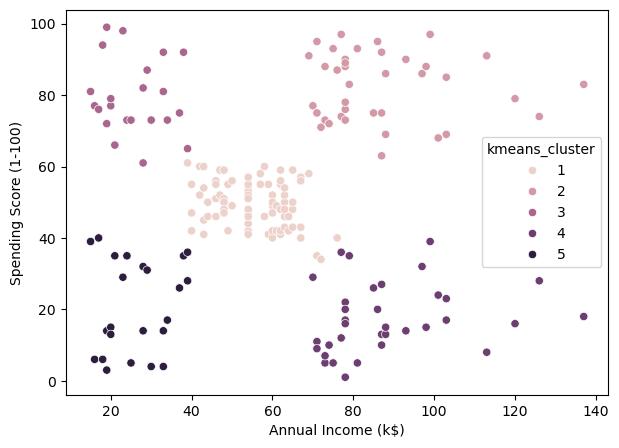

In [13]:
#Plot the visual of cluster
import seaborn as sns
plt.figure(figsize = (7,5))
sns.scatterplot(x = df['Annual Income (k$)'], 
                y = df['Spending Score (1-100)'],
                hue = df['kmeans_cluster'])
plt.show()

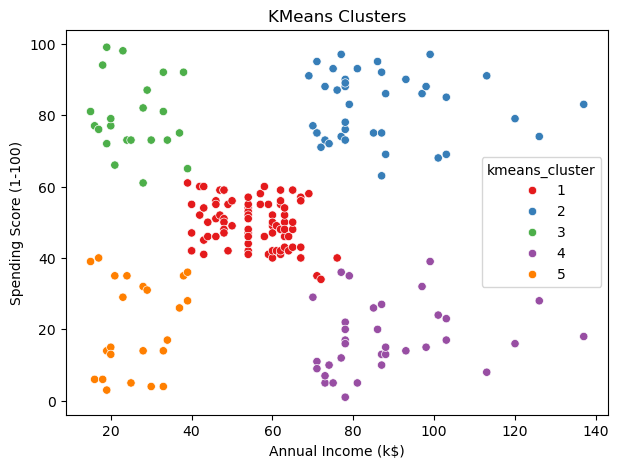

In [14]:
#Coloring of the clusters
plt.figure(figsize = (7,5))
sns.scatterplot(x = df['Annual Income (k$)'], 
                y = df['Spending Score (1-100)'],
                hue = df['kmeans_cluster'],
                palette = 'Set1')
plt.title('KMeans Clusters')
plt.show()

In [15]:
#Step 8 - Cluster Analysis
df.groupby('kmeans_cluster').mean(numeric_only = True)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
kmeans_cluster,,,,
1,86.320988,42.716049,55.296296,49.518519
2,162.000000,32.692308,86.538462,82.128205
3,23.090909,25.272727,25.727273,79.363636
4,164.371429,41.114286,88.200000,17.114286
5,23.000000,45.217391,26.304348,20.913043


# Hierarchical Clustering

# 1.) Agglomerative Clustering

In [16]:
from sklearn.cluster import AgglomerativeClustering
hc_agg = AgglomerativeClustering()
df['HC_Cluster'] = hc_agg.fit_predict(X_scaled)
df['HC_Cluster'] = df['HC_Cluster'] + 1

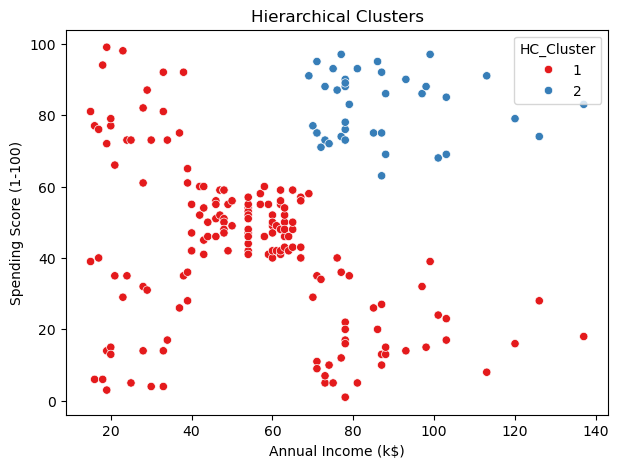

In [17]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = df['Annual Income (k$)'], 
                y = df['Spending Score (1-100)'],
                hue = df['HC_Cluster'],
                palette = 'Set1')
plt.title('Hierarchical Clusters')
plt.show()

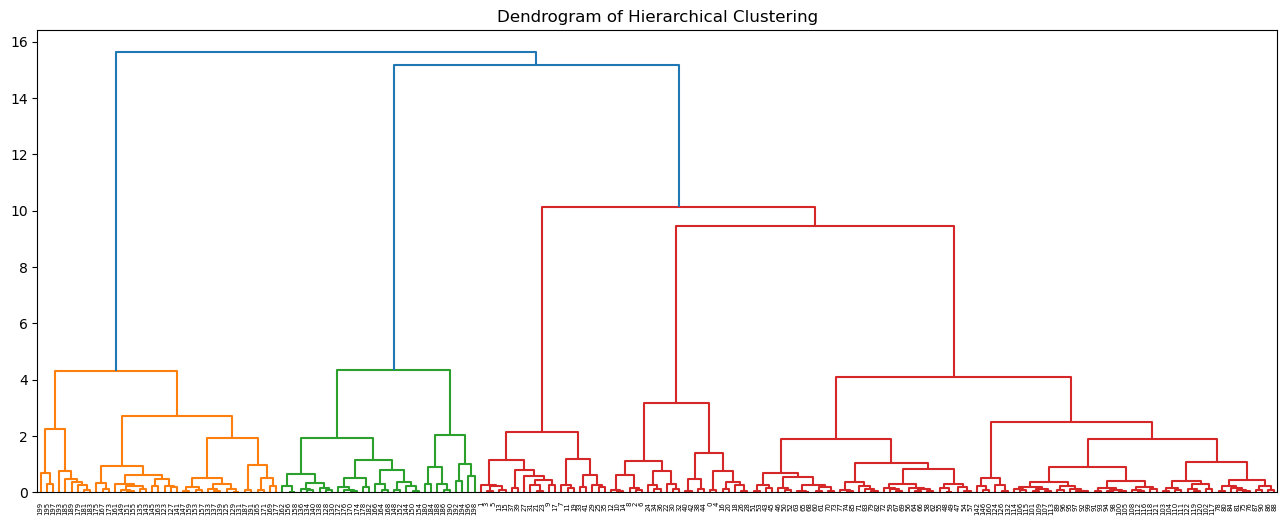

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage
linked = linkage(X_scaled, method = 'ward')
plt.figure(figsize = (16,6))
dendrogram(linked)
plt.title('Dendrogram of Hierarchical Clustering')
plt.show()

# DB Scan

In [19]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps = 0.5, min_samples = 5)

df["DBSCAN_Cluster"] = db.fit_predict(X_scaled)
df["DBSCAN_Cluster"] = df["DBSCAN_Cluster"].apply(
    lambda x: "Noise"if x == -1 else f"Cluster {x+1}"
)

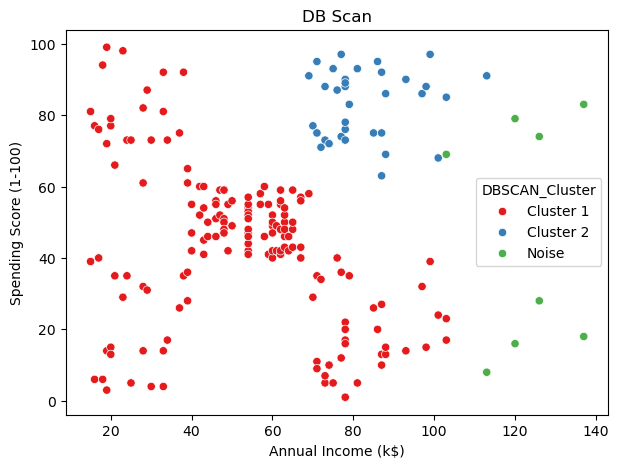

In [20]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = df['Annual Income (k$)'], 
                y = df['Spending Score (1-100)'],
                hue = df['DBSCAN_Cluster'],
                palette = 'Set1')
plt.title('DB Scan')
plt.show()

# Principal Component Analysis (PCA)

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [36]:
wine = load_wine()
X = wine.data
y = wine.target

In [41]:
print(X.shape)
print(y.shape)
print(X_scaled.shape)
print(X_pca.shape)

(178, 13)
(178,)
(200, 2)
(200, 2)


In [42]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

PCA is sdimension reduction concept where is temp

In [43]:
pca = PCA(n_components = 2)

X_pca = pca.fit_transform(X_scaled)

In [44]:
print("Explained Variance Ration: ", pca.explained_variance_ratio_)

Explained Variance Ration:  [0.50495142 0.49504858]


In [45]:
import pandas as pd
pca_df = pd.DataFrame(X_pca, columns = ['PC1','PC2'])

pca_df['target'] = y

ValueError: Length of values (178) does not match length of index (200)

In [ ]:
plt.figure(figsize=(8,6))

for i in pca_df